# Assumptions of Linear Regression

In [51]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels
import scipy as sp

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [52]:
df = pd.read_csv("../data/data.csv")
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [53]:
X = df.drop(columns=["target"])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
residual = y_test - y_pred

## 1-- Linear relationship between input and output

### Use scatterplots

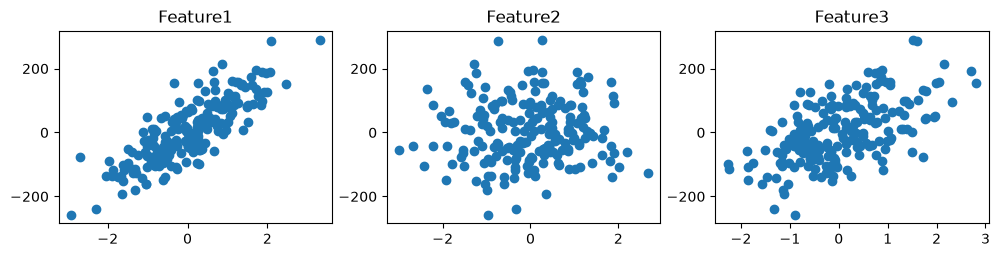

In [55]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

In [56]:
# Feature1 v/s target -- linear
# Feature2 v/s target -- Non linear
# Feature3 v/s target -- somewhat linear

## 2-- No Multicollinearity

### M1 -- Use Vif(variance inflation factor)

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [58]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.001999,1.0113,1.011173


In [59]:
# As vif is close to 1, there is low multicollinearity

### M2 -- Find correlation matrix and draw a heatmap and if values close to 0 -- less multicollinearity

<Axes: >

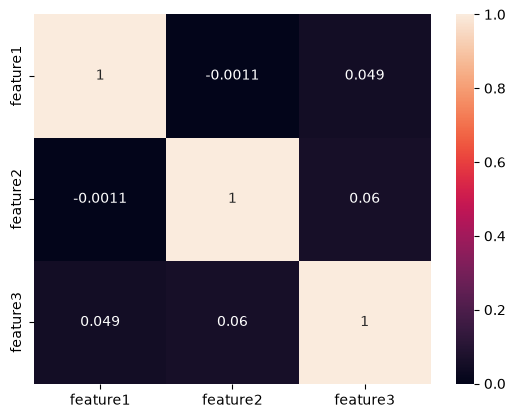

In [60]:
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

In [61]:
# Low Multicollinearity

# 3-- Normal Residual 

### M1 -- Draw displot/histplot/kdeplot

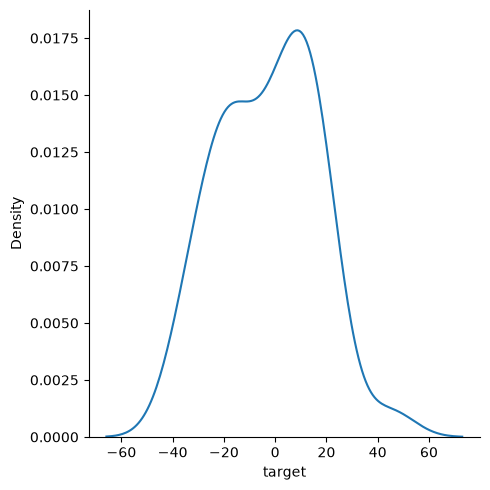

In [62]:
sns.displot(residual,kind='kde')

### M2 -- Draw QQ plot

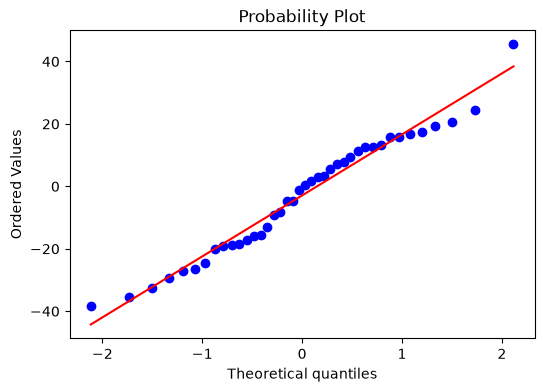

In [63]:
fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

In [64]:
# Normal distribution of residuals is there!

# 4-- Homoscedasticity

### Check spread of residuals(plot scatterplot of y_pred v/s residuals) -- spread should be uniform!

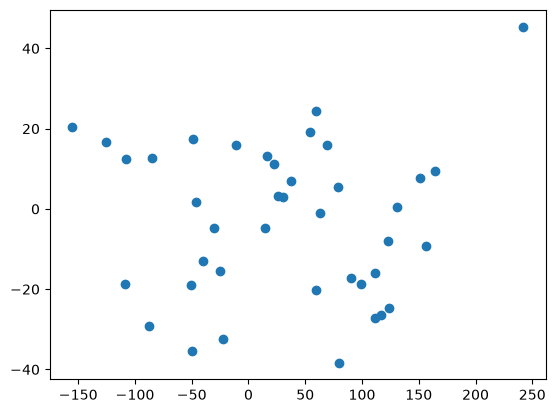

In [65]:
plt.scatter(y_pred,residual)

In [66]:
# Kind of uniform, so homoscedasticity is there!

# 5-- Autocorrelation of residuals

### Plot the residual

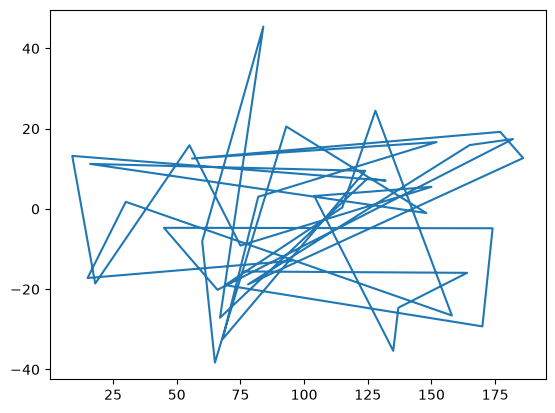

In [67]:
plt.plot(residual)

In [68]:
# Since there is no pattern, there is no autocorrelation of errors which is desirable!

In [69]:
# done :)